![Logo](img/Recurso.png)
## Nombre: Steven Chuiza
### Fecha: 26/05/2026

In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, 100, -10, -11, 13, 19, 100, 100])
print(X)

[  0.5  23.    0.3   4.5   0.3   0.5 -28.  -50.   60.  100.  -10.  -11.
  13.   19.  100.  100. ]


In [2]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  20.13125
mediana:  2.5
moda : 100.0


In [3]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 34.525
limite inferior : -54.06249999999999
limite superior : 84.0375


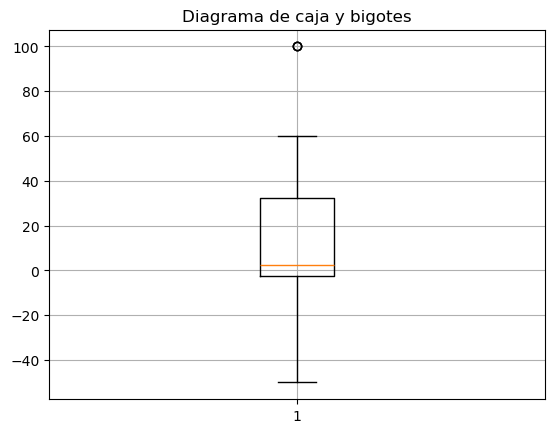

In [4]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [5]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  44.51169395156177
Varianza:  1981.2908984375003


In [6]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  0.7391
Curtosis  -0.5068
Distribución Platicúrtica


In [7]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
from scipy.stats import skew, kurtosis
iris = datasets.load_iris()
#pprint(iris)
X = iris.data
y = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???
longitud_petalo = X[:, 2]

asimetria = skew(longitud_petalo)

print("Asimetría:", asimetria)

if asimetria > 0:
    print("La variable presenta asimetría positiva (sesgo hacia la derecha).")
elif asimetria < 0:
    print("La variable presenta asimetría negativa (sesgo hacia la izquierda).")
else:
    print("La variable tiene una distribución simétrica.")


# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
#???
ancho_sepalo = X[:, 1]

curt = kurtosis(ancho_sepalo)

print("Curtosis:", curt)

if curt > 0:
    print("La distribución es leptocúrtica.")
elif curt < 0:
    print("La distribución es platicúrtica.")
else:
    print("La distribución es mesocúrtica.")

Asimetría: -0.2721276664567214
La variable presenta asimetría negativa (sesgo hacia la izquierda).
Curtosis: 0.18097631752246768
La distribución es leptocúrtica.


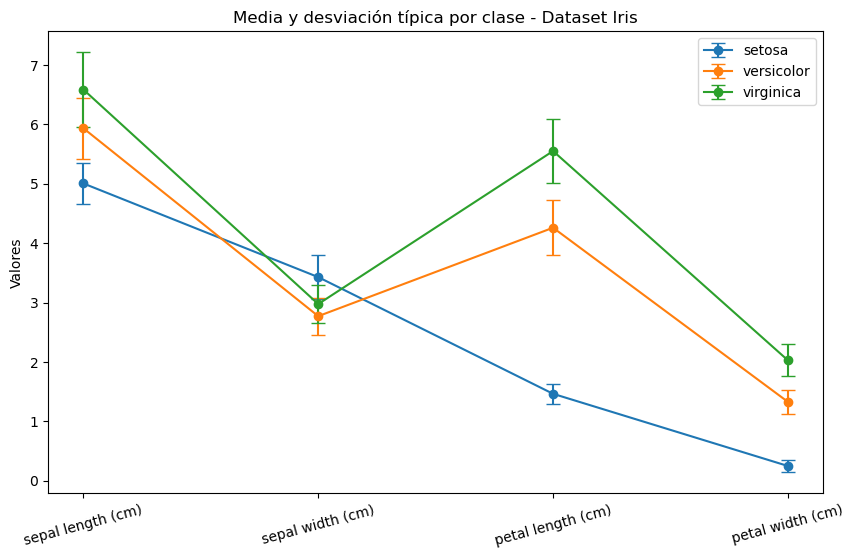

In [8]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)
# Nombres de variables
variables = iris.feature_names

# Clases
clases = np.unique(y)

# Crear figura
plt.figure(figsize=(10,6))

# Recorrer cada clase
for clase in clases:
    
    # Filtrar datos por clase
    datos_clase = X[y == clase]
    
    # Calcular media
    media = np.mean(datos_clase, axis=0)
    
    # Calcular desviación típica
    desviacion = np.std(datos_clase, axis=0)
    
    # Graficar con barras de error
    plt.errorbar(
        range(len(variables)),
        media,
        yerr=desviacion,
        marker='o',
        capsize=5,
        label=iris.target_names[clase]
    )

# Configuración del gráfico
plt.xticks(range(len(variables)), variables, rotation=15)
plt.ylabel("Valores")
plt.title("Media y desviación típica por clase - Dataset Iris")
plt.legend()

plt.show()

El resultado debería ser algo como esto:
<img src="images/errorbar.png">

Repostorio de GitGuhb: https://github.com/tiven29/Fundamentos_Machine_Learning